In [10]:
from IPython.display import clear_output, display, Markdown, HTML
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
import random
import time

import utils.dataset_generation as generate


In [83]:
### Functions (temporary, move to generate once ready)

## Production functions

def session_start(initial_timestamp, mu, sigma, max_days=180):
    # Convert initial timestamp to pandas Timestamp
    initial_time = pd.Timestamp(initial_timestamp)

    # Generate lognormal distribution
    seconds_after = np.random.lognormal(mean=mu, sigma=sigma)#, size=num_samples)

    # Limit timescale to max_days
    max_seconds = max_days * 24 * 60 * 60  # Convert days to seconds
    if seconds_after > max_seconds:
        return None

    session_start_time = initial_time + pd.Timedelta(seconds=seconds_after)
    return session_start_time


def session_end(mean, std_dev, start_timestamp=None):
    """
    Generate a timestamp offset from the start using a bounded normal distribution.

    Parameters:
        start_timestamp (str or pd.Timestamp): Starting timestamp in 'YYYY-MM-DD HH:MM:SS' format.
        mean (float): Mean of the normal distribution (in seconds).
        std_dev (float): Standard deviation of the normal distribution (in seconds).

    Returns:
        pd.Timestamp: Generated timestamp.
    """

    # Define bounds (2 standard deviations)
    lower_bound = mean - 2 * std_dev
    upper_bound = mean + 2 * std_dev

    # Generate a valid value within bounds
    while True:
        value = np.random.normal(loc=mean, scale=std_dev)
        if lower_bound <= value <= upper_bound:
            break

    # Rescale the distribution to fit within the bounds
    scaled_value = value

    # Add the offset to the starting timestamp (if given)
    if start_timestamp is not None:
        # Convert start_timestamp to pandas Timestamp
        start_time = pd.Timestamp(start_timestamp)
        generated_timestamp = start_time + pd.Timedelta(seconds=scaled_value)
    else:
        generated_timestamp = None

    return scaled_value, generated_timestamp



## Auxiliary functions

def find_lognormal_params(target_mode, target_range, tolerance=0.01):
    """
    Determine suitable mu and sigma for a lognormal distribution with the given mode and range.

    Parameters:
        target_mode (float): Desired mode of the distribution (in seconds).
        target_range (tuple): Desired range (in seconds) where most values should fall.
        tolerance (float): Allowed deviation from 68% probability within the range.

    Returns:
        tuple: (mu, sigma) for the lognormal distribution.
    """
    # Define range bounds
    lower_bound, upper_bound = target_range

    best_probability = 0

    # Iterate over possible sigma values
    for sigma in np.linspace(0.1, 1.0, 1000):
        # Calculate mu based on the mode equation
        mu = np.log(target_mode) + sigma**2
        
        # Calculate the CDF at the range bounds
        cdf_lower = lognorm.cdf(lower_bound, s=sigma, scale=np.exp(mu))
        cdf_upper = lognorm.cdf(upper_bound, s=sigma, scale=np.exp(mu))
        
        # Check if the cumulative probability within the range meets the tolerance

        new_probability = cdf_upper - cdf_lower

        if new_probability > best_probability:
            best_probability = new_probability

        if (new_probability) >= (1 - tolerance):
            return mu, sigma, new_probability

    raise ValueError(f"Suitable parameters not found within the given tolerance.  Best probability reached: {best_probability}")


def plot_session_start_distribution(initial_timestamp, mu, sigma, num_samples=1000, max_days=180, time_unit='seconds'):
    """
    Plot the distribution of session start times based on a lognormal distribution.

    Parameters:
        initial_timestamp (str): Initial session start time in 'YYYY-MM-DD HH:MM:SS' format.
        mu (float): Mean (log scale) for the lognormal distribution.
        sigma (float): Standard deviation (log scale) for the lognormal distribution.
        num_samples (int): Number of samples to generate for the lognormal distribution.
        max_days (int): Maximum number of days after the initial timestamp to consider.
        time_unit (str): Unit for x-axis ('seconds', 'minutes', 'hours', 'days').

    Returns:
        None: Displays the plot.
    """
    # Time unit conversion factors
    time_factors = {
        'seconds': 1,
        'minutes': 60,
        'hours': 3600,
        'days': 86400
    }

    if time_unit not in time_factors:
        raise ValueError("Invalid time_unit. Choose from 'seconds', 'minutes', 'hours', or 'days'.")

    # Convert initial timestamp to pandas Timestamp
    initial_time = pd.Timestamp(initial_timestamp)

    # Generate lognormal distribution
    seconds_after = np.random.lognormal(mean=mu, sigma=sigma, size=num_samples)

    # Limit timescale to max_days
    max_seconds = max_days * 24 * 60 * 60  # Convert days to seconds
    seconds_after = seconds_after[seconds_after <= max_seconds]

    # Scale seconds_after based on the selected time_unit
    scaled_values = seconds_after / time_factors[time_unit]

    # Create a histogram for visualization
    count, bins, _ = plt.hist(scaled_values, bins=100, density=True, alpha=0.5, color='blue', align='mid')

    # Generate PDF for the lognormal distribution
    x = np.linspace(min(bins), max(bins), 10000)
    pdf = (np.exp(-(np.log(x * time_factors[time_unit]) - mu)**2 / (2 * sigma**2)) /
           (x * time_factors[time_unit] * sigma * np.sqrt(2 * np.pi))) * time_factors[time_unit]
    plt.plot(x, pdf, linewidth=2, color='red', label='Lognormal PDF')

    # Plot settings
    plt.title('Session Start Time Distribution')
    plt.xlabel(f'Time After Initial Session ({time_unit})')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Show plot
    plt.show()

    # Optional: Print the first few session times for inspection
    print("First few session start times:")
    session_start_times = [initial_time + pd.Timedelta(seconds=sec) for sec in seconds_after]
    print(pd.Series(session_start_times).sort_values().head(10))


def plot_session_length_distribution(mu, sigma, num_samples=1000, max_seconds=86400, time_unit='minutes'):
    """
    Plot the distribution of session lengths based on a lognormal distribution.

    Parameters:
        mu (float): Mean (log scale) for the lognormal distribution.
        sigma (float): Standard deviation (log scale) for the lognormal distribution.
        num_samples (int): Number of samples to generate for the lognormal distribution.
        max_seconds (int): Maximum session length to consider (in seconds).
        time_unit (str): Unit for x-axis ('seconds', 'minutes', 'hours', 'days').

    Returns:
        None: Displays the plot.
    """
    # Time unit conversion factors
    time_factors = {
        'seconds': 1,
        'minutes': 60,
        'hours': 3600,
        'days': 86400
    }

    if time_unit not in time_factors:
        raise ValueError("Invalid time_unit. Choose from 'seconds', 'minutes', 'hours', or 'days'.")

    # Generate session lengths using the session_end function
    session_lengths = []
    for _ in range(num_samples):
        scaled_value, _ = session_end(mean=mu, std_dev=sigma)
        if scaled_value <= max_seconds:  # Ensure lengths are within max_seconds
            session_lengths.append(scaled_value)

    # Convert session lengths to the selected time unit
    scaled_values = np.array(session_lengths) / time_factors[time_unit]

    # Create a histogram for visualization
    count, bins, _ = plt.hist(scaled_values, bins=100, density=True, alpha=0.5, color='blue', align='mid')

    # Generate PDF for the bounded normal distribution
    x = np.linspace(min(bins), max(bins), 1000)
    pdf = (
        np.exp(-0.5 * ((x * time_factors[time_unit] - mu) / sigma)**2)
        / (sigma * np.sqrt(2 * np.pi))
    ) * time_factors[time_unit]
    plt.plot(x, pdf, linewidth=2, color='red', label='Bounded Normal PDF')

    # Plot settings
    plt.title('Session Length Distribution (Bounded Normal)')
    plt.xlabel(f'Session Length ({time_unit})')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Show plot
    plt.show()

    # Optional: Print the first few session lengths for inspection
    print("First few session lengths:")
    print(pd.Series(scaled_values).sort_values().head(10))





In [11]:
legend = {
    'a': 'whale',
    'b': 'babylon',
    'c': 'grind set',
    'd': 'skin-veeti',
    'e': 'purchase curious',
    'f': 'churned',
    'g': 'free to play',
}

print(legend.get('c'))

grind set


In [6]:
cluster_shares = {
    'a': 0,
    'b': 10,
    'c': 0,
    'd': 10,
    'e': 0,
    'f': 0,
    'g': None,
}


customers_dict = generate.initial_clusters(
    cohort_size=100000,
    shares=cluster_shares
    )

display(customers_dict)


{0: 'g',
 1: 'g',
 2: 'g',
 3: 'g',
 4: 'g',
 5: 'b',
 6: 'g',
 7: 'g',
 8: 'd',
 9: 'g',
 10: 'b',
 11: 'g',
 12: 'g',
 13: 'g',
 14: 'g',
 15: 'g',
 16: 'g',
 17: 'g',
 18: 'g',
 19: 'd',
 20: 'g',
 21: 'g',
 22: 'g',
 23: 'g',
 24: 'g',
 25: 'd',
 26: 'g',
 27: 'g',
 28: 'g',
 29: 'g',
 30: 'g',
 31: 'g',
 32: 'g',
 33: 'g',
 34: 'g',
 35: 'g',
 36: 'g',
 37: 'b',
 38: 'g',
 39: 'g',
 40: 'g',
 41: 'd',
 42: 'b',
 43: 'g',
 44: 'g',
 45: 'g',
 46: 'g',
 47: 'g',
 48: 'g',
 49: 'g',
 50: 'g',
 51: 'b',
 52: 'g',
 53: 'g',
 54: 'g',
 55: 'g',
 56: 'g',
 57: 'g',
 58: 'b',
 59: 'g',
 60: 'g',
 61: 'g',
 62: 'g',
 63: 'g',
 64: 'g',
 65: 'g',
 66: 'g',
 67: 'g',
 68: 'b',
 69: 'g',
 70: 'g',
 71: 'g',
 72: 'g',
 73: 'g',
 74: 'g',
 75: 'g',
 76: 'g',
 77: 'g',
 78: 'b',
 79: 'd',
 80: 'd',
 81: 'g',
 82: 'd',
 83: 'g',
 84: 'g',
 85: 'g',
 86: 'g',
 87: 'g',
 88: 'g',
 89: 'g',
 90: 'g',
 91: 'd',
 92: 'b',
 93: 'b',
 94: 'g',
 95: 'g',
 96: 'g',
 97: 'g',
 98: 'g',
 99: 'g',
 100: 'g',

In [7]:
df = generate.installation_timestamps(customers_dict, '2024-01-01', 31)
df = df.sort_values(by='timestamp', ascending=True)
display(df)

,customer_id,cluster,timestamp
60869,60869,d,2024-01-01 00:01:18
29251,29251,g,2024-01-01 00:01:44
7682,7682,g,2024-01-01 00:02:30
76641,76641,g,2024-01-01 00:03:17
78240,78240,g,2024-01-01 00:03:20
...,...,...,...
57810,57810,g,2024-01-31 23:58:21
99319,99319,g,2024-01-31 23:58:33
33375,33375,g,2024-01-31 23:58:59
42026,42026,d,2024-01-31 23:59:17


c:\Users\PyryHuhtanen\Documents\GitHub\Portfolio\customer_acquisition_analytics\utils\dataset_generation.py:212: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



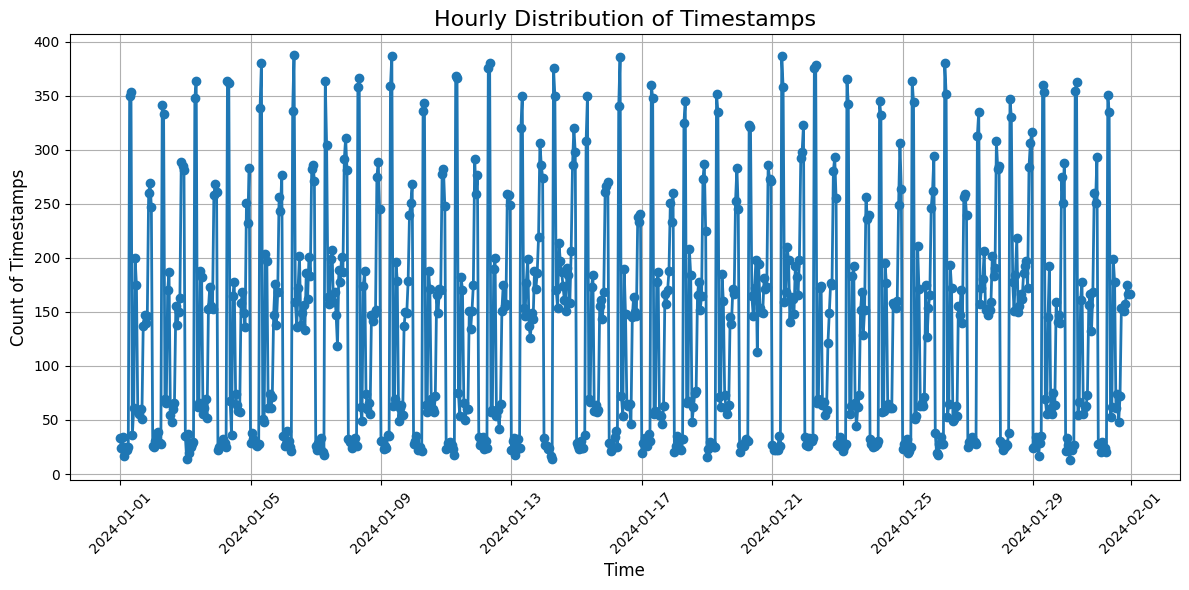

In [7]:
generate.plot_hourly_distribution(df=df)

In [8]:
generate.plotly_hourly_distribution(df=df)

,index,hour,count
0,0,2024-01-01 00:00:00,33
1,1,2024-01-01 01:00:00,26
2,2,2024-01-01 02:00:00,24
3,3,2024-01-01 03:00:00,27
4,4,2024-01-01 04:00:00,26
...,...,...,...
739,739,2024-01-31 19:00:00,155
740,740,2024-01-31 20:00:00,160
741,741,2024-01-31 21:00:00,140
742,742,2024-01-31 22:00:00,159


In [17]:
def cluster_attributes() -> dict:
    a_stats = {}  # Whale

    b_stats = {  # Babylonin lammas
        'session_start_mu': 13.1685,#13.123,
        'session_start_sigma': 0.1,#0.23
        'session_length_mu': 3600,  # 1 hour in seconds
        'session_length_sigma': 600  # 10 minutes in seconds
    }

    c_stats = {}  # Grind set

    d_stats = {  # Skin-Veeti
        'session_start_mu': 9.99,#10.684,#13.123,
        'session_start_sigma': 0.1#0.23
    }

    e_stats = {}  # Purchase curious

    f_stats = {}  # Churned

    g_stats = {  # Free to play
        'session_start_mu': 11.3,#11.78,#12.07,#13.123,
        'session_start_sigma': 0.2#0.23
    }


    cluster_stats = {
        'a': a_stats,
        'b': b_stats,
        'c': c_stats,
        'd': d_stats,
        'e': e_stats,
        'f': f_stats,
        'g': g_stats,
    }

    return cluster_stats


In [36]:
# Define the target mode and range
#target_mode = 6 * 24 * 60 * 60  # 6 days in seconds
#target_range = (5 * 24 * 60 * 60, 7 * 24 * 60 * 60)  # 5 to 7 days in seconds

target_mode = 36 * 60 * 60  # 12 hours in seconds
target_range = (12 * 60 * 60, 2 * 24 * 60 * 60)  # 5 to 7 days in seconds


# Find parameters
mu, sigma, probability = find_lognormal_params(target_mode, target_range, tolerance=0.01)
print(f"Mu: {mu}, Sigma: {sigma}, probability: {probability}")


Mu: 11.782208062900311, Sigma: 0.1, probability: 0.997255327634967


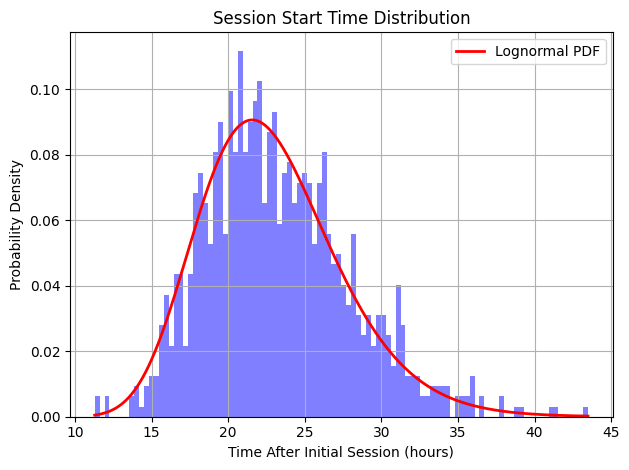

First few session start times:
609   2024-01-01 11:17:24.491940752
698   2024-01-01 11:25:44.658205360
709   2024-01-01 11:58:21.665681494
865   2024-01-01 11:59:07.037247805
236   2024-01-01 13:36:19.268821873
734   2024-01-01 13:37:57.896936141
869   2024-01-01 14:00:57.610033561
24    2024-01-01 14:03:34.932029478
368   2024-01-01 14:07:03.398944989
154   2024-01-01 14:16:57.895587817
dtype: datetime64[ns]


In [54]:
cluster_stats = cluster_attributes()

timestamp='2024-01-01 00:00:00'
mu_g = cluster_stats.get('g').get('session_start_mu')
sigma_g = cluster_stats.get('g').get('session_start_sigma')

plot_session_start_distribution(initial_timestamp=timestamp,
                                mu=mu_g,
                                sigma=sigma_g,
                                num_samples=1000,
                                time_unit='hours'
                                )

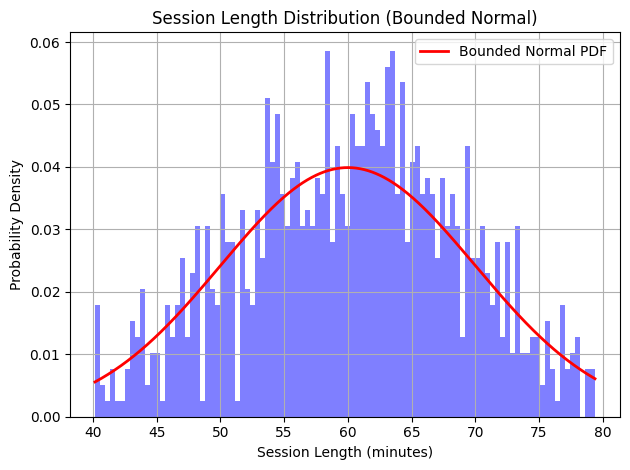

First few session lengths:
233    40.155884
919    40.207344
760    40.217302
846    40.298878
177    40.354759
993    40.488040
728    40.492587
872    40.581018
499    40.816296
253    41.132161
dtype: float64


: 

In [84]:
cluster_stats = cluster_attributes()

mu_length_b = cluster_stats.get('b').get('session_length_mu')
sigma_length_b = cluster_stats.get('b').get('session_length_sigma')

plot_session_length_distribution(
    mu=mu_length_b,
    sigma=sigma_length_b
)

In [82]:
cluster_stats = cluster_attributes()

timestamp='2024-01-01 00:00:00'
mu_start_b = cluster_stats.get('b').get('session_start_mu')
sigma_start_b = cluster_stats.get('b').get('session_start_sigma')

start = session_start(
    initial_timestamp=timestamp,
    mu=mu_start_b,
    sigma=sigma_start_b
    )

mu_length_b = cluster_stats.get('b').get('session_length_mu')
sigma_length_b = cluster_stats.get('b').get('session_length_sigma')


if start is not None:
    session_length, end = session_end(
        mean=mu_length_b,
        std_dev=sigma_length_b,
        start_timestamp=start
    )
else:
    end = None

print(f'''
      Session started at {start}
      Session ended at {end}]''')




      Session started at 2024-01-06 22:32:25.924050055
      Session ended at 2024-01-06 23:28:24.773644162]


In [18]:
# TODO:
# [x] Create function for checking timestamp and moving it up or down based on nighttime, workday, weekend
#   [x] Revisit for not initial

# [x] Generate initial df for each customer installation time (timeframe start, timeframe length (days)
#   [x] Inside function there is even distribution random, and timestamp mover (for night, weekend, workday)
#   [x] cOutput: Dataframe with id, initial cluster, and first intallation timestamp

# [x] Revisit generating new user clusters - Likelihood instead of straight up deterministic number

# [] Auxiliary functions for visualizing
#   [x] Lognormal distribution
#   [x] Normal distribution
#   [] Session cumulation and churn for cluster
#   [] Purchase revenue cumulation (absolute and per cluster participant)
#   [] Original cluster participant status share over time

# [] Dictionary where for each cluster, there is dictionary containing at least following:
#   [x] Distribution of next session start (lognormal)
#   [x] Length of next session (normal, bounded and scaled)
#   [] Dictionary containing likelihood of changing cluster after session end
#   [] Dictionary of likelihoods of there being a certain type of purchase (Event, cosmetic, general internal currency for advancing game)
#   [] Dictionary of distributions of the purchase taking place (lognormal) for each type - generated from start and since last transaction until end
#       of session, so multiple transactions can take place for keen users
#   [] Distribution of size of each transaction (maybe just an array of sizes and set probabilities)
#   [] Distribution of activities:
#       [] Visit skin store
#       [] Visit other resource sink
#       [] Progress game proper (build resource base)
#       [] Do a match in game proper (test of skill)
#       [] Browse events

# [o] Build skeleton on how to proceed with
#   [o] checking each activity
#   [o] loop through sessions until end of timeframe
#   [o] and log activities
#   [o] and log churned into churn list
#   [o] And pass the churn list to recursive function which will check the reactivation, generate sessions, activities, and churn for reactivated,
#       and recursively pass new churn list to itself if not empty (will be empty if none reactivates, or none reactivated churns again)

# [] Now I have pandas dataframe logging for each user for timeframe fct_user_action:
#   [] User id
#   [] Activity Timestamp
#   [] Activity type (install, transaction (type), activity a to e)
#   [] Related session id (user-id-dash-running-session-id)
#   [] Related session start timestamp
#   [] Related session end timestamp
#   [] OG cluster
#   [] Related session started cluster (churned if reactivated)
#   [] Related session ended cluster (e.g. churned or silently churned)

In [24]:
def main():
    
    # Generate dictionary of user clusters
    cluster_shares = {
        'a': 0,
        'b': 10,
        'c': 0,
        'd': 10,
        'e': 0,
        'f': 0,
        'g': None,
    }
    users_dict = generate.initial_clusters(
        cohort_size=100000,
        shares=cluster_shares
        )
    

    # Generate installation timestamps for all users
    df = generate.installation_timestamps(customers_dict, '2024-01-01', 31)


    ## Start main part of user action generation
    # pseudocode
    # for each user id
#       Add installation to df_fct_user_action
#       start_cluster = og_cluster
#       While session_end < 180 days from start of the timeframe:
#           if first session and 80%:
#               bounding_timestamp = installation_timestamp
#               80% chance: First session on installation
#           elif first session and 20% chance:
#               bounding_timestamp = installation_timestamp
#               session_start(initial_timestamp=installation_timestamp)
#               adjust_timestamps(session_start, start=installation_timestamp) -> pd.Timestamp
#           else:
#               bounding_timestamp = previous_session_end
#               session_start(initial_timestamp=bounding_timestamp)
#               adjust_timestamps(session_start, start=bounding_timestamp) -> pd.Timestamp
#           session_length, session_end = session_end(mean=mu_length_user_cluster, std_dev=sigma_length_user_cluster, start_timestamp=start)
#           
#           if session_start > 180 days from start of the timeframe:
#               break
#           Randomize new cluster for session end cluster
#           -> Now I have for this session: user, session_id (generate this, running number), session start,
#               session length, session end, og cluster, session start cluster, session end cluster
#           Start generating actions (think this through later, basically loop each action start time from session start
#               until goes over session end, disregard last)
#           Append activity timestamps, type, transaction size, etc. with all user and session specific attributes to df_fct_user_action
#           user_cluster = end_cluster
#               if user_cluster == f (churned):
#                   Append user with last session end timestamp to df_churned
#                   break
#
#   x = recursive_reactivation(df_churned, date_of_end)
#   for z in x:
#       append to fct_user_action



# def recursive_reactivation(df_churned, date_of_end):
#   df_churned_new = pd.df.empty
#   for each user: Roll date of reactivation (if any: chance of reactivating + timestamp of reactivation)
#       If reactivates AND date of reactivation < date_of_end:
#           Session at the moment of reactivation
#           Basic session stuff
#           yield user action row
#           if session end_cluster = f AND session_end_time < date_of_end
#               Append user with last session end timestamp to df_churned_new
#   if df_churned_new is not empty:
#       yield from recursive_reactivation(df_churned_new, date_of_end)



In [23]:
#print(random.choice([1,2,3,4,5,6]))

def recursive():
    die_roll = random.choice([1, 2, 3, 4, 5, 6])
    yield die_roll
    if die_roll != 6:
        time.sleep(1)
        yield from recursive()

x = recursive()

for z in x:
    if z != 6:
        print(f'Rolled {z}, rolling again')
    else:
        print(f'Rolled {z}, no more rolling')

Rolled 4, rolling again
Rolled 1, rolling again
Rolled 6, no more rolling
